In [17]:
import pandas as pd
from pathlib import Path
from shapely.geometry import box
import pickle
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

In [2]:
# --------------- Paths -------------------------------------------------------------------------------
DATA_DIR = Path("./data")
ATTRIBUTES_FILE = Path('./data/attributes/attributes_caravan.csv')
location_file = Path('./data/attributes/attributes_other.csv')
basins_path = Path("./basins_excluded.txt")

In [6]:
with open(basins_path, "r") as f:
    basins = f.read().splitlines()

In [10]:
attributes_df = pd.read_csv(ATTRIBUTES_FILE)
attributes_df = attributes_df[attributes_df["gauge_id"].isin(basins)]
attributes_df.head()

,gauge_id,aridity_ERA5_LAND,aridity_FAO_PM,frac_snow,high_prec_dur,high_prec_freq,low_prec_dur,low_prec_freq,moisture_index_ERA5_LAND,moisture_index_FAO_PM,p_mean,pet_mean_ERA5_LAND,pet_mean_FAO_PM,seasonality_ERA5_LAND,seasonality_FAO_PM
23,camels_01181000,3.812841,0.517986,0.223071,1.100840,0.053799,3.200636,0.620192,-0.695785,0.505404,3.765760,14.358241,1.950612,0.370373,0.891910
31,camels_01411300,6.547902,0.850316,0.000000,1.119197,0.061054,3.687100,0.671047,-0.840849,0.202124,3.046962,19.951210,2.590882,0.108187,1.124564
40,camels_01440400,4.253795,0.574181,0.215014,1.122053,0.055373,3.328762,0.631348,-0.741846,0.456636,3.511197,14.935913,2.016063,0.243502,0.926743
46,camels_01487000,2.148131,0.816437,0.000000,1.140236,0.059548,3.677091,0.667967,-0.488015,0.228381,3.132572,6.729175,2.557548,0.497987,1.042386
47,camels_01491000,3.867294,0.828633,0.000000,1.126599,0.060301,3.702376,0.671800,-0.724998,0.220911,3.062986,11.845469,2.538091,0.219745,1.061539


In [13]:
basins_without_snow = attributes_df[attributes_df["frac_snow"] == 0]
basins_without_snow

,gauge_id,aridity_ERA5_LAND,aridity_FAO_PM,frac_snow,high_prec_dur,high_prec_freq,low_prec_dur,low_prec_freq,moisture_index_ERA5_LAND,moisture_index_FAO_PM,p_mean,pet_mean_ERA5_LAND,pet_mean_FAO_PM,seasonality_ERA5_LAND,seasonality_FAO_PM
31,camels_01411300,6.547902,0.850316,0.0,1.119197,0.061054,3.687100,0.671047,-0.840849,0.202124,3.046962,19.951210,2.590882,0.108187,1.124564
46,camels_01487000,2.148131,0.816437,0.0,1.140236,0.059548,3.677091,0.667967,-0.488015,0.228381,3.132572,6.729175,2.557548,0.497987,1.042386
47,camels_01491000,3.867294,0.828633,0.0,1.126599,0.060301,3.702376,0.671800,-0.724998,0.220911,3.062986,11.845469,2.538091,0.219745,1.061539
82,camels_01644000,6.478690,0.786511,0.0,1.146575,0.057290,3.723380,0.672553,-0.831573,0.262752,2.882359,18.673912,2.267007,0.166854,1.113510
84,camels_01664000,6.257002,0.787302,0.0,1.160563,0.056400,3.757483,0.670226,-0.827592,0.263094,2.907870,18.194550,2.289372,0.154660,1.079264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
477,camels_08200000,5.892580,1.480150,0.0,1.338816,0.055715,5.378307,0.695756,-0.818055,-0.206494,2.355404,13.879405,3.486350,0.179898,0.972996
478,camels_08202700,5.354751,1.543873,0.0,1.343802,0.055647,5.494394,0.704381,-0.799316,-0.236503,2.294640,12.287230,3.542635,0.203036,0.963851
510,camels_09484600,7.586109,3.427976,0.0,1.458609,0.060301,8.970454,0.810472,-0.844949,-0.632137,1.021377,7.748279,3.501256,0.309929,0.862510
547,camels_11124500,18.177790,2.793685,0.0,1.534381,0.053457,14.039216,0.882135,-0.916015,-0.427672,1.197652,21.770658,3.345862,0.244175,1.529678


In [20]:
basins_without_snow_list = basins_without_snow["gauge_id"]
basins_without_snow_list.to_csv("basins_without_snow.txt", index=False, header=False)

In [25]:
location = pd.read_csv(location_file)
location_without_snow = location[location["gauge_id"].isin(basins_without_snow_list)]
location_without_snow

,gauge_id,gauge_name,country,gauge_lat,gauge_lon,area
31,camels_01411300,TUCKAHOE RIVER AT HEAD OF RIVER NJ,United States of America,39.30694,-74.82056,79.230476
46,camels_01487000,"NANTICOKE RIVER NEAR BRIDGEVILLE, DE",United States of America,38.72833,-75.56186,187.283875
47,camels_01491000,"CHOPTANK RIVER NEAR GREENSBORO, MD",United States of America,38.99719,-75.78581,291.553355
82,camels_01644000,"GOOSE CREEK NEAR LEESBURG, VA",United States of America,39.01955,-77.57749,858.811596
84,camels_01664000,"RAPPAHANNOCK RIVER AT REMINGTON, VA",United States of America,38.53068,-77.81360,1603.511552
...,...,...,...,...,...,...
477,camels_08200000,"Hondo Ck nr Tarpley, TX",United States of America,29.56967,-99.24671,249.577750
478,camels_08202700,"Seco Ck at Rowe Ranch nr D'Hanis, TX",United States of America,29.37079,-99.28782,431.340606
510,camels_09484600,"PANTANO WASH NEAR VAIL, AZ.",United States of America,32.03591,-110.67758,1241.049373
547,camels_11124500,SANTA CRUZ C NR SANTA YNEZ CA,United States of America,34.59666,-119.90875,192.472798


In [18]:
def plot_nse_map(RUN_PREFIX,NSE_THRESHOLD=None):
    """
    Plot NSE values from the latest model_epoch directory with basemap.
    
    Parameters:
    -----------
    run_dir_name : str or Path
        Name of the run directory inside './runs'.
    period : str or Path
        Subdirectory under the run directory (e.g., 'validation').
    """
    
    file_path = f"runs/{RUN_PREFIX}/validation/model_epoch030/validation_results.p"


    with open(file_path, "rb") as f:
        data = pickle.load(f)

    print(f"Loaded {len(data)} catchments")

    nse_values = {"catchment": [], "nse_values": []}

    for catchment in data.keys():

        NSE = data[catchment]["1D"]["NSE"]
        nse_values["catchment"].append(catchment)
        nse_values["nse_values"].append(NSE)

    # Load attributes
    attributes = pd.read_csv(location_file) #.set_index("gauge_id")

    # Create GeoDataFrame
    gdf = gpd.GeoDataFrame(
        attributes,
        geometry=gpd.points_from_xy(attributes["gauge_lon"], attributes["gauge_lat"]),
        crs="EPSG:4326"
    )

    gdf["NSE"] = gdf["gauge_id"].map(dict(zip(nse_values["catchment"], nse_values["nse_values"])))
    gdf = gdf.dropna(subset=["NSE"])

    # Convert to Web Mercator for basemap
    gdf_web = gdf.to_crs(epsg=3857)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    plot = gdf_web.plot(
        column="NSE",
        cmap="viridis",
        legend=True,
        markersize=60,
        ax=ax,
        vmin=0,
        vmax=1
    )

    # Add colorbar label
    cbar = plot.get_figure().get_axes()[1]
    cbar.set_ylabel("ensemble_nse", rotation=270, labelpad=15)

    ax.set_title("NSE by Gauge Location")

    # Define CONUS bounds in lat/lon
    conus_bounds = box(-125, 24, -66.5, 50)  # (minx, miny, maxx, maxy)

    # Convert to GeoDataFrame and project to Web Mercator
    conus_gdf = gpd.GeoDataFrame(geometry=[conus_bounds], crs="EPSG:4326")
    conus_gdf_web = conus_gdf.to_crs(epsg=3857)

    # Extract projected bounds
    xmin, ymin, xmax, ymax = conus_gdf_web.total_bounds

    # Set fixed extent
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

    # Add basemap
    cx.add_basemap(ax, source=cx.providers.CartoDB.Voyager)

    plt.show()

Loaded 241 catchments


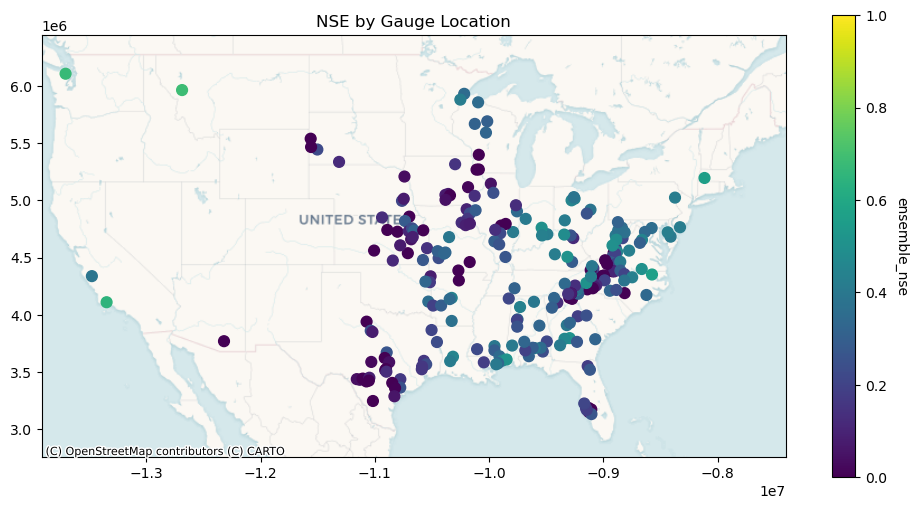

In [19]:
RUN_PREFIX = "caravan_precip_seq_270_30_epochs_hidden_256_dropout_04_fb_05_seed111_0103_185008"
plot_nse_map(RUN_PREFIX)